# L2.6 — Финансовая модель SaaS-продукта

## Что такое финансовая модель цифрового продукта?

Финансовая модель — это математическое описание экономики продукта, которое позволяет:

- **Прогнозировать** выручку, расходы и прибыль на горизонте 1–3 года
- **Оценивать** влияние ключевых метрик (конверсия, отток, ARPU) на финансовый результат
- **Принимать решения** об инвестициях, ценообразовании, найме
- **Анализировать риски** через сценарный анализ и симуляции Монте-Карло

В этом ноутбуке мы построим полную P&L-модель SaaS-сервиса: от входного трафика до кумулятивного денежного потока. Затем добавим сценарный анализ, анализ чувствительности (tornado chart) и стохастическую симуляцию.

**Структура:**
1. Входные параметры
2. Функция модели
3. Визуализация базового сценария
4. Юнит-экономика (LTV, CAC, Payback)
5. NPV и дисконтированная окупаемость
6. Три сценария (пессимистичный / базовый / оптимистичный)
7. Анализ чувствительности (Tornado chart)
8. Монте-Карло симуляция
9. Бонус: данные из реального датасета
10. Ключевые выводы

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.rcParams.update({
    'figure.facecolor': '#1e2027',
    'axes.facecolor': '#1e2027',
    'axes.edgecolor': '#ffffff',
    'axes.labelcolor': '#ffffff',
    'text.color': '#ffffff',
    'xtick.color': '#ffffff',
    'ytick.color': '#ffffff',
    'grid.color': '#ffffff',
    'figure.figsize': (14, 8),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ACCENT = '#ff5533'
GREEN = '#22c55e'
RED = '#ef4444'

print('Библиотеки загружены. Стиль графиков настроен.')

Библиотеки загружены. Стиль графиков настроен.


---
## 1. Входные параметры

Определим ключевые метрики SaaS-продукта. Каждый параметр — это рычаг, который мы сможем менять в сценарном анализе.

In [5]:
params = {
    'traffic_month0': 10_000,   # начальный трафик (визитов/мес)
    'traffic_growth':  0.05,    # рост трафика +5% в месяц
    'conversion':      0.03,    # конверсия в платящих: 3%
    'arpu':            1_500,   # средний чек: 1 500 руб./мес
    'churn':           0.05,    # месячный отток: 5%
    'cac':             5_000,   # стоимость привлечения клиента
    'server_pct':      0.10,    # серверные расходы: 10% от MRR
    'team_cost':       500_000, # фонд оплаты труда: 500К/мес
}

HORIZON = 24  # горизонт модели: 24 месяца

# Вывод параметров в виде таблицы
desc = {
    'traffic_month0': 'Начальный трафик (визитов/мес)',
    'traffic_growth':  'Рост трафика (мес.)',
    'conversion':      'Конверсия в платящих',
    'arpu':            'ARPU (руб./мес)',
    'churn':           'Месячный отток',
    'cac':             'CAC (руб.)',
    'server_pct':      'Серверные расходы (% от MRR)',
    'team_cost':       'Фонд оплаты труда (руб./мес)',
}

params_df = pd.DataFrame([
    {'Параметр': desc[k], 'Значение': f'{v:,.0f}' if isinstance(v, int) else f'{v:.0%}' if v < 1 else f'{v:,.0f}'}
    for k, v in params.items()
])
print(f'Горизонт модели: {HORIZON} месяцев\n')
params_df

Горизонт модели: 24 месяцев



,Параметр,Значение
0,Начальный трафик (визитов/мес),"10,000"
1,Рост трафика (мес.),5%
2,Конверсия в платящих,3%
3,ARPU (руб./мес),"1,500"
4,Месячный отток,5%
5,CAC (руб.),"5,000"
6,Серверные расходы (% от MRR),10%
7,Фонд оплаты труда (руб./мес),"500,000"


---
## 2. Функция модели

Функция `build_model()` принимает словарь параметров и горизонт, возвращает DataFrame с помесячной финансовой моделью.

**Логика расчёта на каждый месяц:**
- Трафик растёт экспоненциально: `traffic_month0 * (1 + growth)^m`
- Новые клиенты = трафик * конверсия
- Отток = активная база * churn
- Активная база = предыдущая + новые - отток
- MRR = активная база * ARPU
- Расходы = CAC на новых + серверы (% от MRR) + команда (фикс)
- EBITDA = выручка - расходы

In [6]:
def build_model(p, horizon=24):
    """
    Построить финансовую модель SaaS-продукта.
    
    Parameters
    ----------
    p : dict
        Словарь параметров модели.
    horizon : int
        Горизонт в месяцах.
    
    Returns
    -------
    pd.DataFrame
        Помесячная таблица с метриками.
    """
    rows = []
    active_base = 0
    cumulative_cf = 0

    for m in range(1, horizon + 1):
        # --- Воронка ---
        traffic = p['traffic_month0'] * (1 + p['traffic_growth']) ** (m - 1)
        new_customers = int(traffic * p['conversion'])
        churned = int(active_base * p['churn'])
        active_base = active_base + new_customers - churned

        # --- Выручка ---
        mrr = active_base * p['arpu']
        revenue = mrr

        # --- Расходы ---
        cost_cac = new_customers * p['cac']
        cost_server = mrr * p['server_pct']
        cost_team = p['team_cost']
        total_costs = cost_cac + cost_server + cost_team

        # --- Прибыль ---
        ebitda = revenue - total_costs
        cumulative_cf += ebitda

        rows.append({
            'month': m,
            'traffic': int(traffic),
            'new_customers': new_customers,
            'churned': churned,
            'active_base': active_base,
            'mrr': round(mrr),
            'revenue': round(revenue),
            'cost_cac': round(cost_cac),
            'cost_server': round(cost_server),
            'cost_team': round(cost_team),
            'total_costs': round(total_costs),
            'ebitda': round(ebitda),
            'cumulative_cf': round(cumulative_cf),
        })

    return pd.DataFrame(rows)

In [7]:
# Построим базовый сценарий
df_base = build_model(params, HORIZON)

# Найдём точку безубыточности по EBITDA
breakeven_rows = df_base[df_base['ebitda'] > 0]
if len(breakeven_rows) > 0:
    be_month = breakeven_rows.iloc[0]['month']
    print(f'Точка безубыточности (EBITDA > 0): месяц {be_month:.0f}')
else:
    be_month = None
    print('Модель не выходит на безубыточность в рамках горизонта.')

print()
df_base[['month', 'traffic', 'new_customers', 'active_base',
         'mrr', 'total_costs', 'ebitda', 'cumulative_cf']].head(12)

Точка безубыточности (EBITDA > 0): месяц 6



,month,traffic,new_customers,active_base,mrr,total_costs,ebitda,cumulative_cf
0,1,10000,300,300,450000,2045000,-1595000,-1595000
1,2,10500,315,600,900000,2165000,-1265000,-2860000
2,3,11025,330,900,1350000,2285000,-935000,-3795000
3,4,11576,347,1202,1803000,2415300,-612300,-4407300
4,5,12155,364,1506,2259000,2545900,-286900,-4694200
5,6,12762,382,1813,2719500,2681950,37550,-4656650
6,7,13400,402,2125,3187500,2828750,358750,-4297900
7,8,14071,422,2441,3661500,2976150,685350,-3612550
8,9,14774,443,2762,4143000,3129300,1013700,-2598850
9,10,15513,465,3089,4633500,3288350,1345150,-1253700


**Инсайт:** Модель наглядно показывает механику SaaS — на старте расходы на привлечение (CAC) превышают выручку от маленькой базы, но по мере роста базы клиентов рекуррентная выручка начинает покрывать все расходы. Точка безубыточности по EBITDA наступает, когда активная база становится достаточно большой.

---
## 3. Визуализация базового сценария

Четыре ключевых графика: рост базы, MRR, помесячная EBITDA и кумулятивный денежный поток.

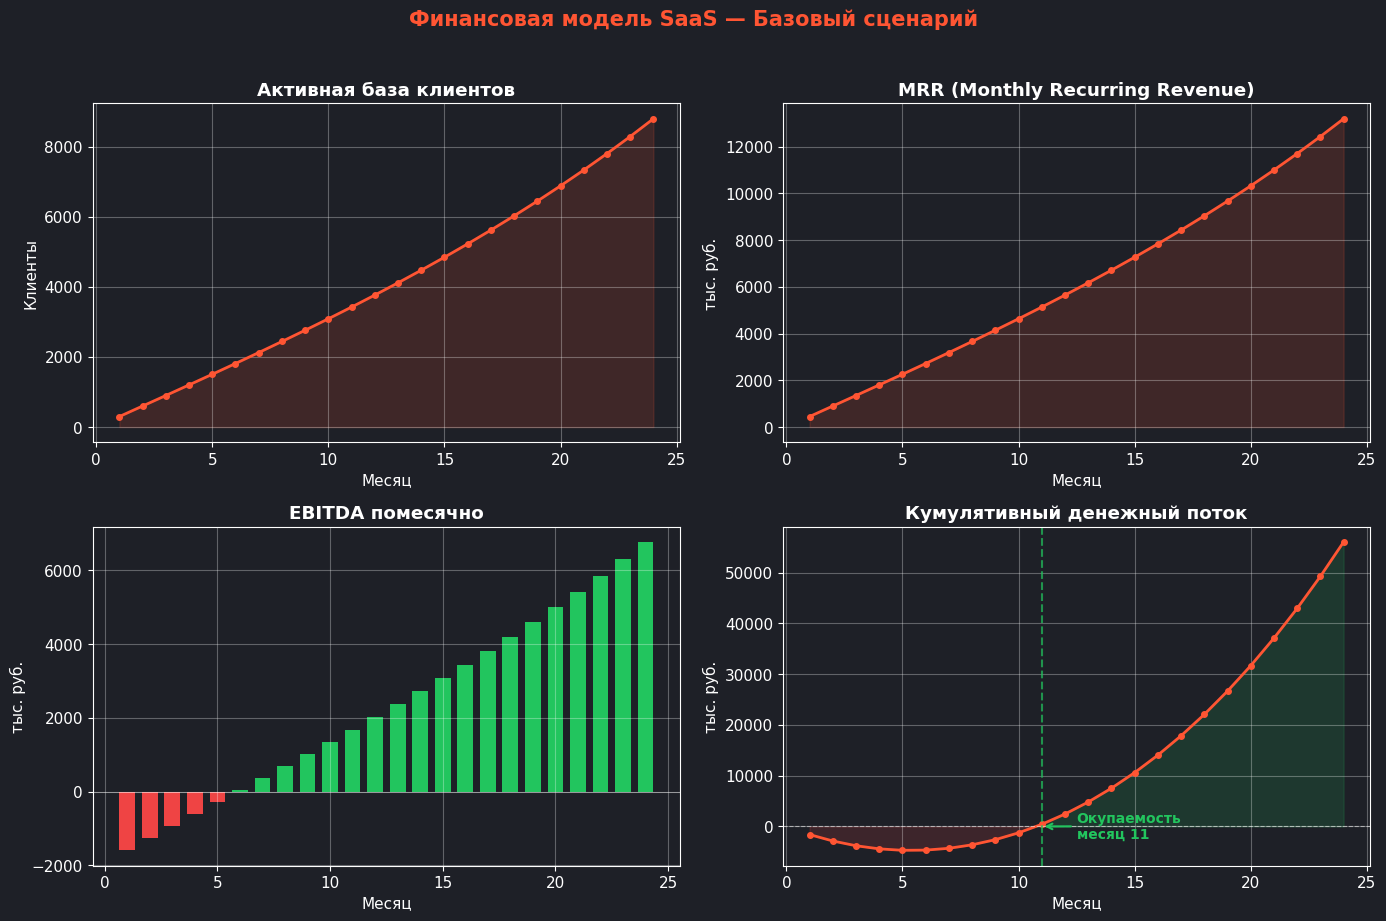

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Активная база
ax = axes[0, 0]
ax.plot(df_base['month'], df_base['active_base'], 'o-',
        color=ACCENT, markersize=4, linewidth=2)
ax.fill_between(df_base['month'], 0, df_base['active_base'],
                color=ACCENT, alpha=0.15)
ax.set_title('Активная база клиентов', fontweight='bold')
ax.set_ylabel('Клиенты')

# 2. MRR
ax = axes[0, 1]
ax.plot(df_base['month'], df_base['mrr'] / 1_000, 'o-',
        color=ACCENT, markersize=4, linewidth=2)
ax.fill_between(df_base['month'], 0, df_base['mrr'] / 1_000,
                color=ACCENT, alpha=0.15)
ax.set_title('MRR (Monthly Recurring Revenue)', fontweight='bold')
ax.set_ylabel('тыс. руб.')

# 3. EBITDA (зелёные/красные бары)
ax = axes[1, 0]
colors_ebitda = [GREEN if v > 0 else RED for v in df_base['ebitda']]
ax.bar(df_base['month'], df_base['ebitda'] / 1_000,
       color=colors_ebitda, edgecolor='none', width=0.7)
ax.axhline(0, color='#ffffff', linewidth=0.5, alpha=0.5)
ax.set_title('EBITDA помесячно', fontweight='bold')
ax.set_ylabel('тыс. руб.')

# 4. Кумулятивный Cash Flow + линия безубыточности
ax = axes[1, 1]
ax.plot(df_base['month'], df_base['cumulative_cf'] / 1_000, 'o-',
        color=ACCENT, markersize=4, linewidth=2)
ax.fill_between(df_base['month'], 0, df_base['cumulative_cf'] / 1_000,
                where=(df_base['cumulative_cf'] >= 0),
                color=GREEN, alpha=0.15, interpolate=True)
ax.fill_between(df_base['month'], 0, df_base['cumulative_cf'] / 1_000,
                where=(df_base['cumulative_cf'] < 0),
                color=RED, alpha=0.15, interpolate=True)
ax.axhline(0, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.5)

# Отметка окупаемости
cf_breakeven = df_base[df_base['cumulative_cf'] > 0]
if len(cf_breakeven) > 0:
    cf_be_month = int(cf_breakeven.iloc[0]['month'])
    ax.axvline(cf_be_month, color=GREEN, linestyle='--', alpha=0.7, linewidth=1.5)
    ax.annotate(f'Окупаемость\nмесяц {cf_be_month}',
                xy=(cf_be_month, 0), xytext=(cf_be_month + 1.5, ax.get_ylim()[0] * 0.3),
                fontsize=10, color=GREEN, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))

ax.set_title('Кумулятивный денежный поток', fontweight='bold')
ax.set_ylabel('тыс. руб.')

for ax in axes.flat:
    ax.set_xlabel('Месяц')

fig.suptitle('Финансовая модель SaaS — Базовый сценарий',
             fontsize=15, fontweight='bold', color=ACCENT, y=1.02)
plt.tight_layout()
plt.show()

**Инсайт:** В первые месяцы EBITDA отрицательна — это нормально для SaaS: компания инвестирует в привлечение базы. По мере роста базы рекуррентная выручка (MRR) начинает превышать расходы. Кумулятивный CF переходит в положительную зону, когда накопленная прибыль компенсирует начальные убытки.

---
## 4. Юнит-экономика

Три ключевые метрики:
- **LTV** (Lifetime Value) = ARPU / Churn — сколько приносит один клиент за всё время
- **CAC** (Customer Acquisition Cost) — сколько стоит привлечение
- **LTV/CAC** — если > 3, бизнес-модель здоровая
- **Payback Period** = CAC / ARPU — через сколько месяцев один клиент окупает привлечение

         ЮНИТ-ЭКОНОМИКА SaaS
  LTV (Lifetime Value):        30,000 руб.
  CAC (Acquisition Cost):       5,000 руб.
  LTV / CAC:                      6.0x
  Payback Period:                 3.3 мес.


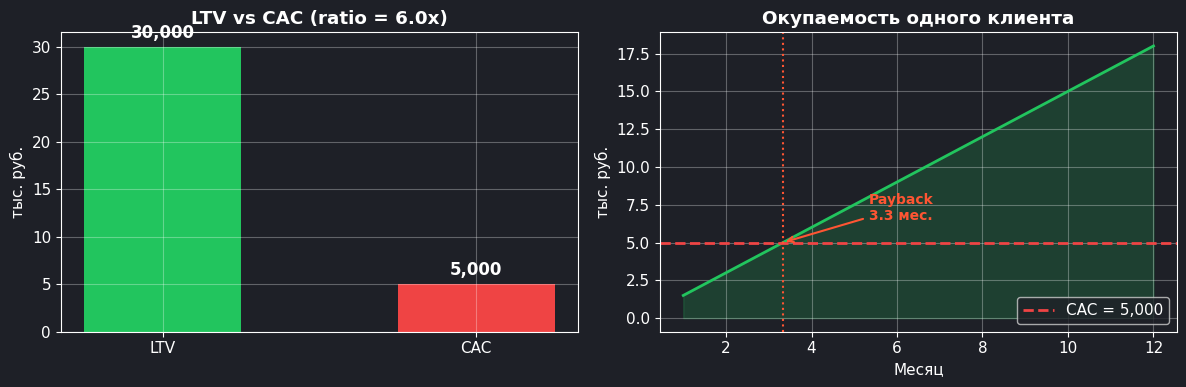

In [9]:
# Юнит-экономика
ltv = params['arpu'] / params['churn']
cac = params['cac']
ltv_cac_ratio = ltv / cac
payback_months = cac / params['arpu']

print('=' * 50)
print('         ЮНИТ-ЭКОНОМИКА SaaS')
print('=' * 50)
print(f'  LTV (Lifetime Value):    {ltv:>10,.0f} руб.')
print(f'  CAC (Acquisition Cost):  {cac:>10,.0f} руб.')
print(f'  LTV / CAC:               {ltv_cac_ratio:>10.1f}x')
print(f'  Payback Period:          {payback_months:>10.1f} мес.')
print('=' * 50)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LTV vs CAC
ax = axes[0]
bars = ax.bar(['LTV', 'CAC'], [ltv / 1000, cac / 1000],
              color=[GREEN, RED], width=0.5, edgecolor='none')
ax.set_ylabel('тыс. руб.')
ax.set_title(f'LTV vs CAC (ratio = {ltv_cac_ratio:.1f}x)', fontweight='bold')
for bar, val in zip(bars, [ltv, cac]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Payback timeline
ax = axes[1]
months_range = np.arange(1, 13)
cumulative_revenue = months_range * params['arpu']
ax.fill_between(months_range, 0, cumulative_revenue / 1000,
                color=GREEN, alpha=0.2)
ax.plot(months_range, cumulative_revenue / 1000, '-', color=GREEN, linewidth=2)
ax.axhline(cac / 1000, color=RED, linestyle='--', linewidth=2, label=f'CAC = {cac:,.0f}')
ax.axvline(payback_months, color=ACCENT, linestyle=':', linewidth=1.5)
ax.annotate(f'Payback\n{payback_months:.1f} мес.',
            xy=(payback_months, cac / 1000),
            xytext=(payback_months + 2, cac / 1000 * 1.3),
            fontsize=10, color=ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5))
ax.set_xlabel('Месяц')
ax.set_ylabel('тыс. руб.')
ax.set_title('Окупаемость одного клиента', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Инсайт:** LTV/CAC = 6.0x — это отличный показатель (бенчмарк для SaaS: >3x). Payback Period = 3.3 месяца — клиент окупает затраты на привлечение менее чем за 4 месяца. Юнит-экономика здоровая, есть запас прочности.

---
## 5. NPV (чистая приведённая стоимость)

NPV дисконтирует будущие денежные потоки к сегодняшнему дню. Ставка дисконтирования 15% годовых отражает альтернативную стоимость капитала.

     NPV-АНАЛИЗ (ставка 15% годовых)
  Месячная ставка дисконтирования: 1.1715%
  NPV (24 мес.):       44,447,229 руб.
  Дисконтированная окупаемость:    месяц 11


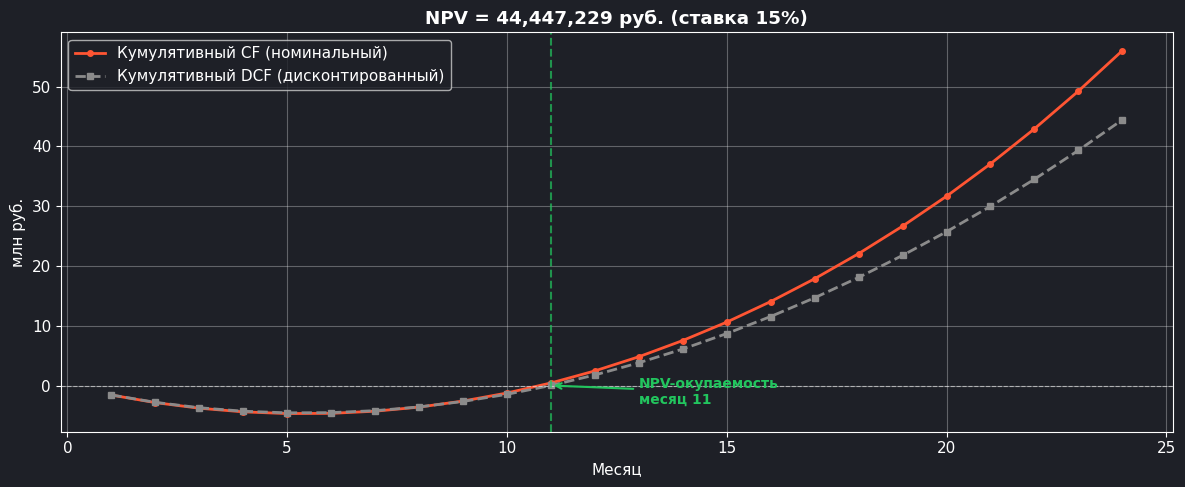

In [10]:
annual_discount_rate = 0.15
monthly_discount_rate = (1 + annual_discount_rate) ** (1/12) - 1

# Рассчитаем дисконтированные потоки
df_base['discount_factor'] = [(1 + monthly_discount_rate) ** (-m) for m in df_base['month']]
df_base['discounted_cf'] = df_base['ebitda'] * df_base['discount_factor']
df_base['cumulative_dcf'] = df_base['discounted_cf'].cumsum()

npv = df_base['discounted_cf'].sum()

# Дисконтированная окупаемость
dcf_positive = df_base[df_base['cumulative_dcf'] > 0]
if len(dcf_positive) > 0:
    npv_payback_month = int(dcf_positive.iloc[0]['month'])
else:
    npv_payback_month = None

print('=' * 50)
print('     NPV-АНАЛИЗ (ставка 15% годовых)')
print('=' * 50)
print(f'  Месячная ставка дисконтирования: {monthly_discount_rate:.4%}')
print(f'  NPV ({HORIZON} мес.):  {npv:>15,.0f} руб.')
if npv_payback_month:
    print(f'  Дисконтированная окупаемость:    месяц {npv_payback_month}')
else:
    print(f'  Дисконтированная окупаемость:    не достигнута')
print('=' * 50)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_base['month'], df_base['cumulative_cf'] / 1_000_000,
        'o-', color=ACCENT, markersize=4, linewidth=2, label='Кумулятивный CF (номинальный)')
ax.plot(df_base['month'], df_base['cumulative_dcf'] / 1_000_000,
        's--', color='#8b8b8b', markersize=4, linewidth=2, label='Кумулятивный DCF (дисконтированный)')
ax.axhline(0, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.5)

if npv_payback_month:
    ax.axvline(npv_payback_month, color=GREEN, linestyle='--', alpha=0.7)
    ax.annotate(f'NPV-окупаемость\nмесяц {npv_payback_month}',
                xy=(npv_payback_month, 0),
                xytext=(npv_payback_month + 2, ax.get_ylim()[0] * 0.4),
                fontsize=10, color=GREEN, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))

ax.set_xlabel('Месяц')
ax.set_ylabel('млн руб.')
ax.set_title(f'NPV = {npv:,.0f} руб. (ставка {annual_discount_rate:.0%})', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Инсайт:** NPV > 0 означает, что проект создаёт стоимость даже с учётом временнoй стоимости денег. Дисконтированная окупаемость наступает позже номинальной — это нормально, ведь далёкие денежные потоки стоят меньше сегодня.

### 5.1 Интерактивный NPV-калькулятор

Двигайте слайдеры, чтобы увидеть, как параметры влияют на **NPV**, **окупаемость** и **прибыльность** проекта. Модель пересчитывается мгновенно.

> **Совет:** попробуйте увеличить отток (churn) до 8–10% — вы увидите, как резко падает NPV и отодвигается точка окупаемости.

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def interactive_npv(discount_rate, churn, conversion, arpu, cac):
    """Пересчитать и показать NPV, окупаемость и графики."""
    p = {**params, 'churn': churn / 100, 'conversion': conversion / 100,
         'arpu': arpu, 'cac': cac}
    df = build_model(p, HORIZON)

    monthly_rate = (1 + discount_rate / 100) ** (1/12) - 1
    df['discount_factor'] = [(1 + monthly_rate) ** (-m) for m in df['month']]
    df['discounted_cf'] = df['ebitda'] * df['discount_factor']
    df['cumulative_dcf'] = df['discounted_cf'].cumsum()
    npv_val = df['discounted_cf'].sum()

    # Окупаемость (номинальная и дисконтированная)
    cf_pos = df[df['cumulative_cf'] > 0]
    cf_payback = int(cf_pos.iloc[0]['month']) if len(cf_pos) > 0 else None
    dcf_pos = df[df['cumulative_dcf'] > 0]
    npv_payback = int(dcf_pos.iloc[0]['month']) if len(dcf_pos) > 0 else None

    # Прибыльность (EBITDA > 0)
    ebitda_pos = df[df['ebitda'] > 0]
    profit_month = int(ebitda_pos.iloc[0]['month']) if len(ebitda_pos) > 0 else None

    # --- Графики ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Кумулятивный CF vs DCF
    ax = axes[0]
    ax.plot(df['month'], df['cumulative_cf'] / 1e6, 'o-',
            color=ACCENT, markersize=3, linewidth=2, label='Номинальный CF')
    ax.plot(df['month'], df['cumulative_dcf'] / 1e6, 's--',
            color='#8b8b8b', markersize=3, linewidth=2, label='Дисконтированный CF')
    ax.axhline(0, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.5)
    if cf_payback:
        ax.axvline(cf_payback, color=GREEN, linestyle='--', alpha=0.7)
        ax.annotate(f'Окупаемость\nмес. {cf_payback}', xy=(cf_payback, 0),
                    xytext=(cf_payback + 1.5, ax.get_ylim()[0] * 0.3 if ax.get_ylim()[0] < 0 else -0.5),
                    fontsize=9, color=GREEN, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
    ax.set_title(f'NPV = {npv_val:,.0f} руб.', fontweight='bold')
    ax.set_xlabel('Месяц')
    ax.set_ylabel('млн руб.')
    ax.legend(fontsize=8)

    # 2. EBITDA помесячно
    ax = axes[1]
    colors_e = [GREEN if v > 0 else RED for v in df['ebitda']]
    ax.bar(df['month'], df['ebitda'] / 1e3, color=colors_e, width=0.7)
    ax.axhline(0, color='#ffffff', linewidth=0.5, alpha=0.5)
    if profit_month:
        ax.set_title(f'EBITDA (прибыльность с мес. {profit_month})', fontweight='bold')
    else:
        ax.set_title('EBITDA (не выходит в плюс)', fontweight='bold')
    ax.set_xlabel('Месяц')
    ax.set_ylabel('тыс. руб.')

    # 3. Юнит-экономика
    ax = axes[2]
    ltv_val = arpu / (churn / 100)
    ltv_cac = ltv_val / cac
    payback_val = cac / arpu
    bars = ax.bar(['LTV', 'CAC'], [ltv_val / 1e3, cac / 1e3],
                  color=[GREEN, RED], width=0.5)
    for bar, val in zip(bars, [ltv_val, cac]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'LTV/CAC = {ltv_cac:.1f}x | Payback = {payback_val:.1f} мес.', fontweight='bold')
    ax.set_ylabel('тыс. руб.')

    plt.tight_layout()
    plt.show()

    # Сводка
    status = '✅ Прибыльный' if npv_val > 0 else '❌ Убыточный'
    print(f'{status}  |  NPV = {npv_val:,.0f} руб.  |  '
          f'Окупаемость: {f"мес. {npv_payback}" if npv_payback else "не достигнута"}  |  '
          f'LTV/CAC = {ltv_cac:.1f}x')

style = {'description_width': '180px'}
layout = widgets.Layout(width='500px')

widgets.interact(
    interactive_npv,
    discount_rate=widgets.FloatSlider(value=15, min=0, max=40, step=1,
                                      description='Ставка дисконт. (%)', style=style, layout=layout),
    churn=widgets.FloatSlider(value=5, min=1, max=15, step=0.5,
                              description='Отток / мес. (%)', style=style, layout=layout),
    conversion=widgets.FloatSlider(value=3, min=0.5, max=10, step=0.5,
                                   description='Конверсия (%)', style=style, layout=layout),
    arpu=widgets.IntSlider(value=1500, min=500, max=5000, step=100,
                           description='ARPU (руб./мес)', style=style, layout=layout),
    cac=widgets.IntSlider(value=5000, min=1000, max=15000, step=500,
                          description='CAC (руб.)', style=style, layout=layout),
);

interactive(children=(FloatSlider(value=15.0, description='Ставка дисконт. (%)', layout=Layout(width='500px'),…

---
## 6. Три сценария

Сценарный анализ показывает диапазон возможных исходов:

| Сценарий | Конверсия | Отток | Рост трафика |
|----------|-----------|-------|-------------|
| Пессимистичный | 2% | 8% | 2% |
| Базовый | 3% | 5% | 5% |
| Оптимистичный | 5% | 3% | 8% |

In [12]:
scenarios = {
    'Пессимистичный': {**params, 'conversion': 0.02, 'churn': 0.08, 'traffic_growth': 0.02},
    'Базовый':        params,
    'Оптимистичный':  {**params, 'conversion': 0.05, 'churn': 0.03, 'traffic_growth': 0.08},
}

scenario_colors = {
    'Пессимистичный': RED,
    'Базовый': ACCENT,
    'Оптимистичный': GREEN,
}

# Построим модели для всех сценариев
scenario_dfs = {}
for name, p in scenarios.items():
    scenario_dfs[name] = build_model(p, HORIZON)

# Сводная таблица на конец горизонта
summary = []
for name, df in scenario_dfs.items():
    last = df.iloc[-1]
    summary.append({
        'Сценарий': name,
        'Активная база': f"{last['active_base']:,.0f}",
        'MRR (тыс.)': f"{last['mrr']/1000:,.0f}",
        'EBITDA M24 (тыс.)': f"{last['ebitda']/1000:,.0f}",
        'Кумулятивный CF (тыс.)': f"{last['cumulative_cf']/1000:,.0f}",
    })
pd.DataFrame(summary)

,Сценарий,Активная база,MRR (тыс.),EBITDA M24 (тыс.),Кумулятивный CF (тыс.)
0,Пессимистичный,"2,948","4,422","1,905","14,545"
1,Базовый,"8,796","13,194","6,770","56,013"
2,Оптимистичный,"26,635","39,952","20,782","160,729"


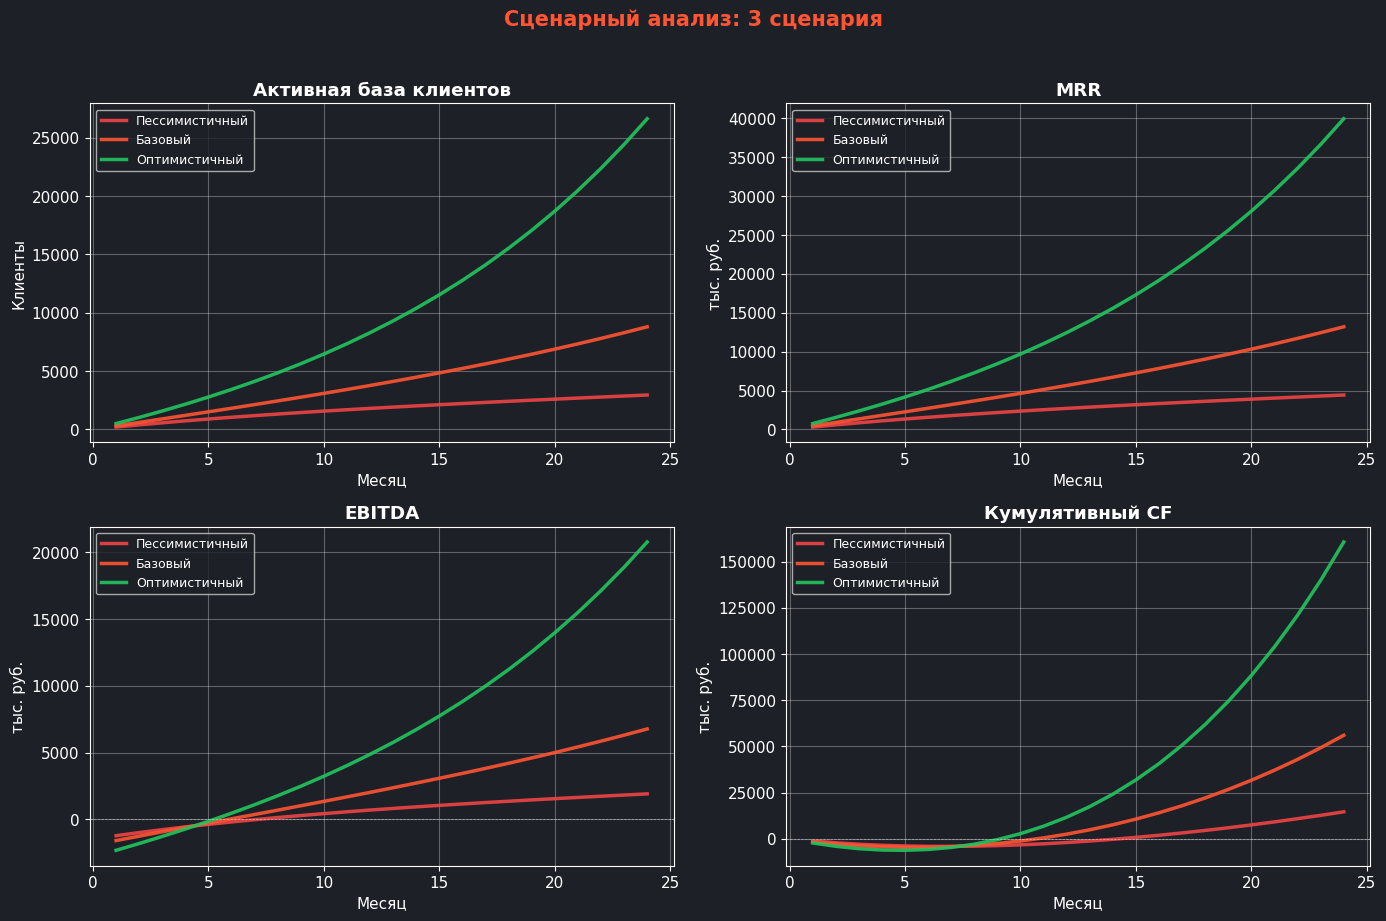

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('active_base', 'Активная база клиентов', 'Клиенты', 1),
    ('mrr', 'MRR', 'тыс. руб.', 1_000),
    ('ebitda', 'EBITDA', 'тыс. руб.', 1_000),
    ('cumulative_cf', 'Кумулятивный CF', 'тыс. руб.', 1_000),
]

for idx, (col, title, ylabel, divisor) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    for name, df in scenario_dfs.items():
        ax.plot(df['month'], df[col] / divisor,
                '-', color=scenario_colors[name], linewidth=2.5,
                label=name, alpha=0.9)
    if col in ('ebitda', 'cumulative_cf'):
        ax.axhline(0, color='#ffffff', linewidth=0.5, alpha=0.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Месяц')
    ax.legend(loc='upper left', fontsize=9)

fig.suptitle('Сценарный анализ: 3 сценария',
             fontsize=15, fontweight='bold', color=ACCENT, y=1.02)
plt.tight_layout()
plt.show()

**Инсайт:** Разброс результатов значительный. В оптимистичном сценарии EBITDA к 24-му месяцу кратно выше базового. В пессимистичном — модель может не выйти на окупаемость кумулятивного CF, что критично для инвестиционного решения. Сценарный анализ помогает оценить диапазон рисков и подготовить план действий.

---
## 7. Анализ чувствительности (Tornado Chart)

Какой параметр сильнее всего влияет на EBITDA? Изменим каждый параметр на ±30% и посмотрим на отклонение EBITDA в 12-м месяце.

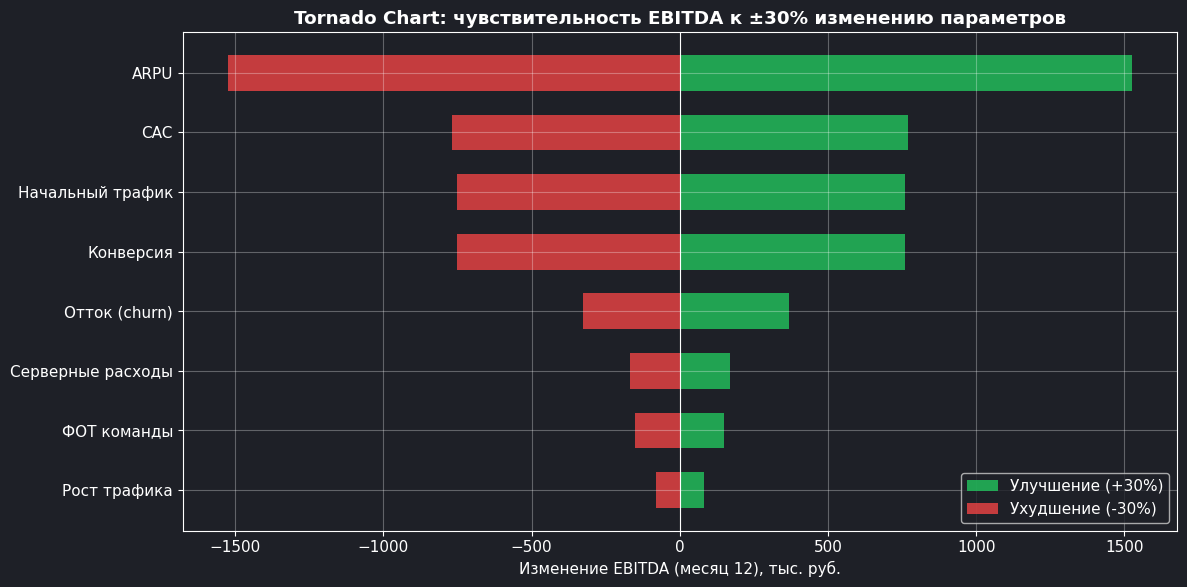


Базовая EBITDA в месяце 12: 2,017,750 руб.

Рейтинг параметров по влиянию (от меньшего к большему):
  Рост трафика               размах:      163 тыс. руб.
  ФОТ команды                размах:      300 тыс. руб.
  Серверные расходы          размах:      339 тыс. руб.
  Отток (churn)              размах:      697 тыс. руб.
  Конверсия                  размах:    1,511 тыс. руб.
  Начальный трафик           размах:    1,511 тыс. руб.
  CAC                        размах:    1,539 тыс. руб.
  ARPU                       размах:    3,050 тыс. руб.


In [14]:
target_month_idx = 11  # месяц 12 (индекс 11)
base_ebitda_12 = df_base.loc[target_month_idx, 'ebitda']
delta_pct = 0.30  # ±30%

param_labels = {
    'churn':          'Отток (churn)',
    'conversion':     'Конверсия',
    'arpu':           'ARPU',
    'cac':            'CAC',
    'traffic_growth': 'Рост трафика',
    'traffic_month0': 'Начальный трафик',
    'server_pct':     'Серверные расходы',
    'team_cost':      'ФОТ команды',
}

sensitivities = {}
for param_name in param_labels.keys():
    p_up = {**params, param_name: params[param_name] * (1 + delta_pct)}
    p_down = {**params, param_name: params[param_name] * (1 - delta_pct)}
    e_up = build_model(p_up).loc[target_month_idx, 'ebitda']
    e_down = build_model(p_down).loc[target_month_idx, 'ebitda']
    sensitivities[param_name] = (e_down - base_ebitda_12, e_up - base_ebitda_12)

# Сортировка по абсолютному влиянию
sorted_params = sorted(sensitivities.keys(),
                       key=lambda k: abs(sensitivities[k][1] - sensitivities[k][0]))

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(sorted_params))

for i, p_name in enumerate(sorted_params):
    low, high = sensitivities[p_name]
    # Зелёная полоска — улучшение, красная — ухудшение
    ax.barh(i, max(low, high) / 1_000, color=GREEN, alpha=0.8, height=0.6,
            label='Улучшение (+30%)' if i == len(sorted_params) - 1 else '')
    ax.barh(i, min(low, high) / 1_000, color=RED, alpha=0.8, height=0.6,
            label='Ухудшение (-30%)' if i == len(sorted_params) - 1 else '')

ax.set_yticks(list(y_pos))
ax.set_yticklabels([param_labels[p] for p in sorted_params])
ax.set_xlabel('Изменение EBITDA (месяц 12), тыс. руб.')
ax.set_title(f'Tornado Chart: чувствительность EBITDA к ±{delta_pct:.0%} изменению параметров',
             fontweight='bold')
ax.axvline(0, color='#ffffff', linewidth=0.8)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Вывод числовых значений
print(f'\nБазовая EBITDA в месяце 12: {base_ebitda_12:,.0f} руб.')
print(f'\nРейтинг параметров по влиянию (от меньшего к большему):')
for p_name in sorted_params:
    low, high = sensitivities[p_name]
    span = abs(high - low)
    print(f'  {param_labels[p_name]:<25s}  размах: {span/1000:>8,.0f} тыс. руб.')

**Инсайт:** Churn (отток) влияет сильнее всего — это типично для SaaS. Снижение оттока на 30% даёт бoльший эффект, чем такое же увеличение конверсии или ARPU. Именно поэтому retention — приоритет номер один для SaaS-продукта.

---
## 8. Монте-Карло симуляция

Сценарный анализ показывает 3 точки. Монте-Карло показывает **распределение** — 5 000 случайных комбинаций параметров с учётом их неопределённости.

Для каждого параметра задаём нормальное распределение с базовым значением как средним и разумным стандартным отклонением.

In [15]:
N_SIM = 5_000
np.random.seed(42)

# Параметры распределений
mc_distributions = {
    'traffic_month0': {'mean': 10_000, 'std': 2_000},
    'traffic_growth':  {'mean': 0.05,   'std': 0.015, 'clip': (0.0, 0.15)},
    'conversion':      {'mean': 0.03,   'std': 0.008, 'clip': (0.005, 0.10)},
    'arpu':            {'mean': 1_500,  'std': 300},
    'churn':           {'mean': 0.05,   'std': 0.015, 'clip': (0.01, 0.15)},
    'cac':             {'mean': 5_000,  'std': 1_000},
}

# Генерируем все параметры сразу (векторизованно)
sim_params = {}
for key, dist in mc_distributions.items():
    values = np.random.normal(dist['mean'], dist['std'], N_SIM)
    if 'clip' in dist:
        values = np.clip(values, dist['clip'][0], dist['clip'][1])
    sim_params[key] = values

# Запуск симуляций
ebitda_12_sims = np.zeros(N_SIM)
ebitda_24_sims = np.zeros(N_SIM)
cumcf_24_sims = np.zeros(N_SIM)

for i in range(N_SIM):
    p = {
        'traffic_month0': sim_params['traffic_month0'][i],
        'traffic_growth':  sim_params['traffic_growth'][i],
        'conversion':      sim_params['conversion'][i],
        'arpu':            sim_params['arpu'][i],
        'churn':           sim_params['churn'][i],
        'cac':             sim_params['cac'][i],
        'server_pct':      0.10,
        'team_cost':       500_000,
    }
    df_sim = build_model(p, HORIZON)
    ebitda_12_sims[i] = df_sim.loc[11, 'ebitda']
    ebitda_24_sims[i] = df_sim.loc[23, 'ebitda']
    cumcf_24_sims[i] = df_sim.loc[23, 'cumulative_cf']

print(f'Завершено {N_SIM:,} симуляций.')

Завершено 5,000 симуляций.


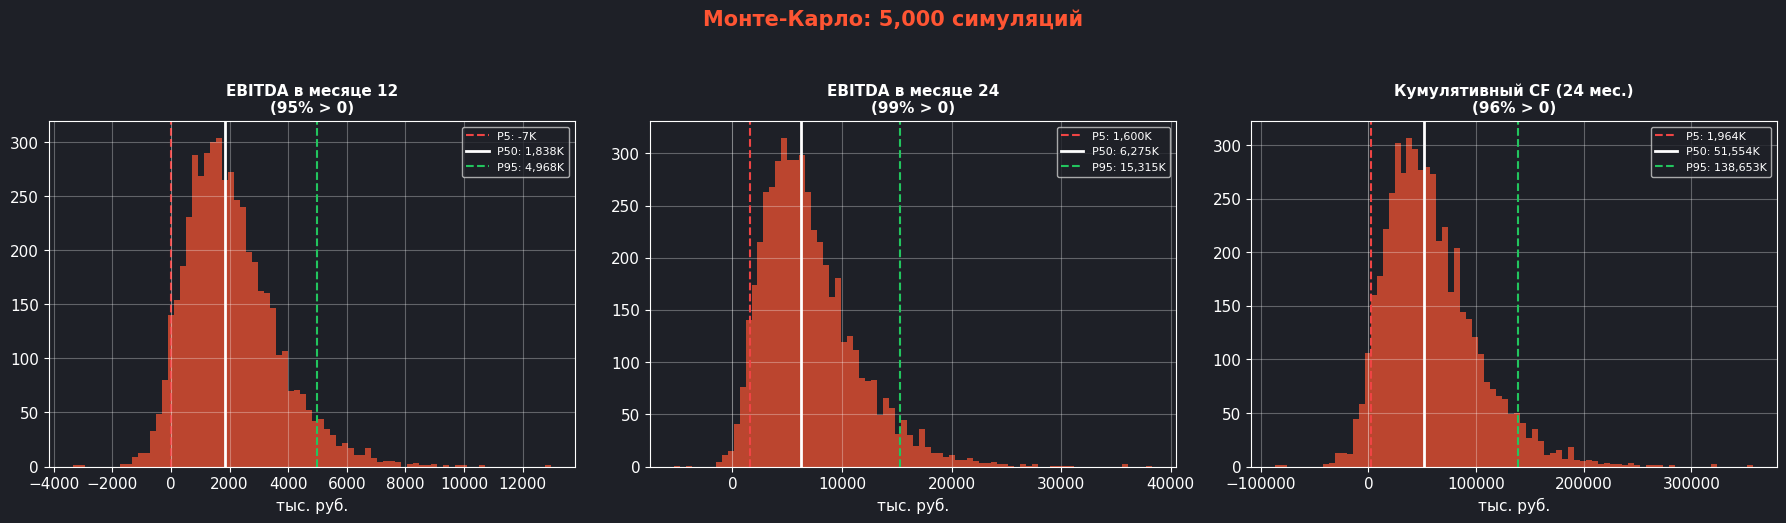

  МОНТЕ-КАРЛО: 5,000 симуляций

  EBITDA в месяце 12:
    P5  (худший):           -6,869 руб.
    P50 (медиана):       1,838,004 руб.
    P95 (лучший):        4,968,025 руб.
    Вероятность > 0:           95%

  EBITDA в месяце 24:
    P5  (худший):        1,600,283 руб.
    P50 (медиана):       6,275,034 руб.
    P95 (лучший):       15,315,497 руб.
    Вероятность > 0:           99%

  Кумулятивный CF (24 мес.):
    P5  (худший):        1,964,034 руб.
    P50 (медиана):      51,553,912 руб.
    P95 (лучший):      138,653,142 руб.
    Вероятность > 0:           96%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (ebitda_12_sims, 'EBITDA в месяце 12'),
    (ebitda_24_sims, 'EBITDA в месяце 24'),
    (cumcf_24_sims, 'Кумулятивный CF (24 мес.)'),
]

for ax, (data, title) in zip(axes, datasets):
    p5, p50, p95 = np.percentile(data, [5, 50, 95])
    pct_positive = (data > 0).mean() * 100

    ax.hist(data / 1_000, bins=80, color=ACCENT, alpha=0.7, edgecolor='none')
    ax.axvline(p5 / 1_000, color=RED, linestyle='--', linewidth=1.5,
               label=f'P5: {p5/1000:,.0f}K')
    ax.axvline(p50 / 1_000, color='#ffffff', linestyle='-', linewidth=2,
               label=f'P50: {p50/1000:,.0f}K')
    ax.axvline(p95 / 1_000, color=GREEN, linestyle='--', linewidth=1.5,
               label=f'P95: {p95/1000:,.0f}K')
    ax.axvline(0, color='#ffffff', linewidth=0.5, alpha=0.3)

    ax.set_title(f'{title}\n({pct_positive:.0f}% > 0)', fontweight='bold', fontsize=11)
    ax.set_xlabel('тыс. руб.')
    ax.legend(fontsize=8)

fig.suptitle(f'Монте-Карло: {N_SIM:,} симуляций',
             fontsize=15, fontweight='bold', color=ACCENT, y=1.04)
plt.tight_layout()
plt.show()

# Итоговая статистика
print('=' * 60)
print(f'  МОНТЕ-КАРЛО: {N_SIM:,} симуляций')
print('=' * 60)
for data, label in datasets:
    p5, p50, p95 = np.percentile(data, [5, 50, 95])
    pct_pos = (data > 0).mean() * 100
    print(f'\n  {label}:')
    print(f'    P5  (худший):     {p5:>12,.0f} руб.')
    print(f'    P50 (медиана):    {p50:>12,.0f} руб.')
    print(f'    P95 (лучший):     {p95:>12,.0f} руб.')
    print(f'    Вероятность > 0:  {pct_pos:>11.0f}%')
print('=' * 60)

**Инсайт:** Монте-Карло показывает не один исход, а целое распределение. Медианный результат (P50) близок к базовому сценарию, но есть длинный хвост убыточных исходов. Вероятность прибыли в месяце 12 и кумулятивная окупаемость к 24 месяцу — ключевые метрики для инвестиционного решения.

---
## 9. Бонус: данные из реального датасета

Загрузим данные из `sales_data.csv`, рассчитаем реальные ARPU и прокси для churn, подставим в модель.

In [17]:
# Загрузка данных
sales = pd.read_csv('../shared/data/sales_data.csv', parse_dates=['date'])
sales['month'] = sales['date'].dt.to_period('M')

print(f'Загружено {len(sales):,} заказов')
print(f'Период: {sales["date"].min().date()} — {sales["date"].max().date()}')
print(f'Уникальных клиентов: {sales["customer_id"].nunique():,}')
sales.head()

Загружено 47,929 заказов
Период: 2024-01-01 — 2024-12-31
Уникальных клиентов: 2,000


,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue,month
0,10090,2024-01-01,C0127,Москва,Соцсети,Продукты,Чай,1,710.0,710.0,2024-01
1,10046,2024-01-01,C0355,Челябинск,Реклама,Книги,Учебник,3,710.0,2130.0,2024-01
2,10002,2024-01-01,C1992,Санкт-Петербург,Реклама,Дом и сад,Кашпо,1,4800.0,4800.0,2024-01
3,10038,2024-01-01,C0176,Москва,Органика,Продукты,Чай,1,1140.0,1140.0,2024-01
4,10059,2024-01-01,C0034,Челябинск,Органика,Красота,Маска,5,1930.0,9650.0,2024-01


In [18]:
# --- Реальный ARPU ---
# Средняя выручка на клиента в месяц
monthly_revenue_per_customer = (
    sales.groupby(['month', 'customer_id'])['revenue']
    .sum()
    .reset_index()
)
real_arpu = monthly_revenue_per_customer['revenue'].mean()

# --- Прокси для Churn ---
# Доля клиентов, купивших в месяце M, но не купивших в M+1
months_sorted = sorted(sales['month'].unique())
churn_rates = []

for i in range(len(months_sorted) - 1):
    m_curr = months_sorted[i]
    m_next = months_sorted[i + 1]

    customers_curr = set(sales[sales['month'] == m_curr]['customer_id'])
    customers_next = set(sales[sales['month'] == m_next]['customer_id'])

    if len(customers_curr) > 0:
        churned = customers_curr - customers_next
        churn_rate = len(churned) / len(customers_curr)
        churn_rates.append(churn_rate)

real_churn = np.mean(churn_rates)

# --- Реальный трафик (уникальные клиенты/мес как прокси) ---
monthly_customers = sales.groupby('month')['customer_id'].nunique()
real_traffic_proxy = monthly_customers.mean()

print('=' * 50)
print('   МЕТРИКИ ИЗ РЕАЛЬНЫХ ДАННЫХ')
print('=' * 50)
print(f'  ARPU (средний чек/мес):   {real_arpu:>10,.0f} руб.')
print(f'  Churn-прокси (мес.):      {real_churn:>10.1%}')
print(f'  Активных клиентов/мес:    {real_traffic_proxy:>10,.0f}')
print('=' * 50)

   МЕТРИКИ ИЗ РЕАЛЬНЫХ ДАННЫХ
  ARPU (средний чек/мес):       14,859 руб.
  Churn-прокси (мес.):           15.8%
  Активных клиентов/мес:         1,682


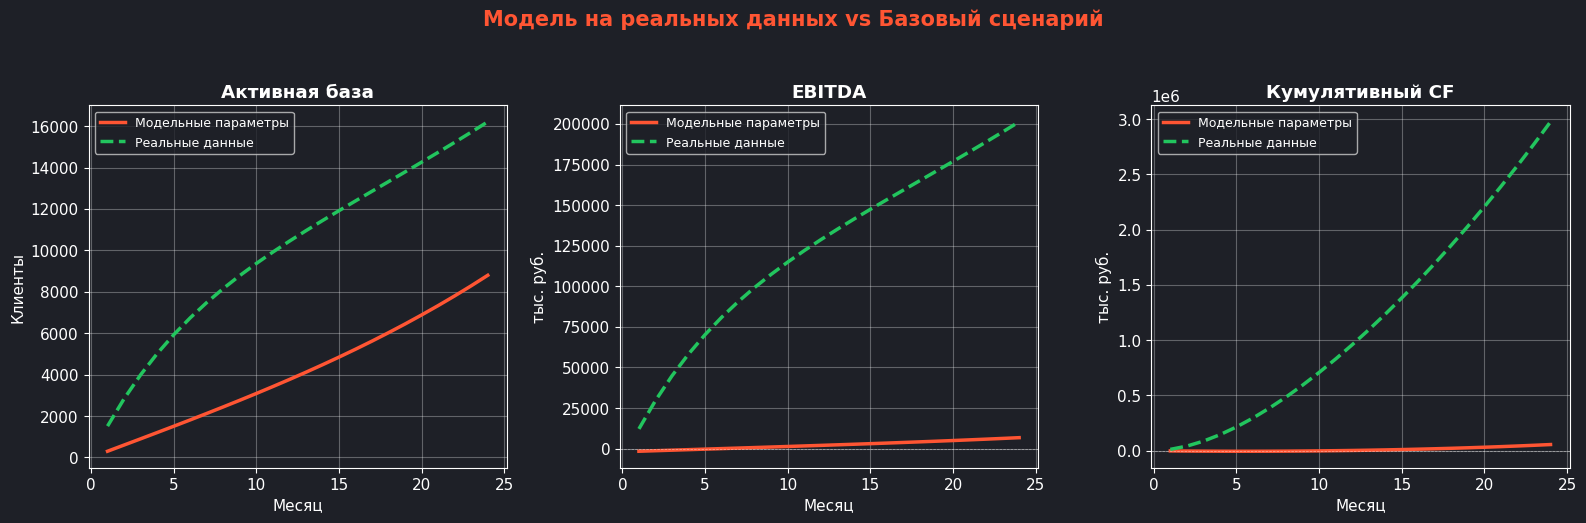


Модель на реальных данных:
  ARPU: 14,859 руб. (модельный: 1,500 руб.)
  Churn: 15.8% (модельный: 5%)
  EBITDA M24: 201,309,858 руб.
  Кумулятивный CF M24: 2,976,347,504 руб.


In [19]:
# Подставляем реальные данные в модель
params_real = {
    'traffic_month0': int(real_traffic_proxy * 30),  # масштабируем до трафика
    'traffic_growth':  0.03,          # консервативный рост
    'conversion':      0.03,          # оставляем базовую конверсию
    'arpu':            real_arpu,     # из данных
    'churn':           real_churn,    # из данных
    'cac':             5_000,         # оставляем как есть
    'server_pct':      0.10,
    'team_cost':       500_000,
}

df_real = build_model(params_real, HORIZON)

# Сравнение: базовая модель vs модель на реальных данных
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparisons = [
    ('active_base', 'Активная база', 'Клиенты', 1),
    ('ebitda', 'EBITDA', 'тыс. руб.', 1_000),
    ('cumulative_cf', 'Кумулятивный CF', 'тыс. руб.', 1_000),
]

for ax, (col, title, ylabel, divisor) in zip(axes, comparisons):
    ax.plot(df_base['month'], df_base[col] / divisor,
            '-', color=ACCENT, linewidth=2.5, label='Модельные параметры')
    ax.plot(df_real['month'], df_real[col] / divisor,
            '--', color=GREEN, linewidth=2.5, label='Реальные данные')
    if col in ('ebitda', 'cumulative_cf'):
        ax.axhline(0, color='#ffffff', linewidth=0.5, alpha=0.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Месяц')
    ax.legend(fontsize=9)

fig.suptitle('Модель на реальных данных vs Базовый сценарий',
             fontsize=15, fontweight='bold', color=ACCENT, y=1.04)
plt.tight_layout()
plt.show()

print(f'\nМодель на реальных данных:')
print(f'  ARPU: {real_arpu:,.0f} руб. (модельный: {params["arpu"]:,} руб.)')
print(f'  Churn: {real_churn:.1%} (модельный: {params["churn"]:.0%})')
print(f'  EBITDA M24: {df_real.iloc[-1]["ebitda"]:,.0f} руб.')
print(f'  Кумулятивный CF M24: {df_real.iloc[-1]["cumulative_cf"]:,.0f} руб.')

**Инсайт:** Модель на реальных данных может существенно отличаться от теоретической. Реальный ARPU и churn из датасета — лучшая основа для прогноза, чем экспертные оценки. Всегда калибруйте модель по фактическим данным, когда они доступны.

---
## 10. Ключевые выводы

1. **Финансовая модель** — это не предсказание, а инструмент мышления. Она показывает, при каких условиях продукт будет прибыльным, и помогает расставить приоритеты.

2. **Юнит-экономика (LTV/CAC)** — первый фильтр. Если LTV/CAC < 3, масштабирование приведёт к убыткам. В нашей модели LTV/CAC = 6.0x — есть запас прочности.

3. **Churn — главный рычаг.** Tornado chart показывает, что снижение оттока влияет на EBITDA сильнее, чем любой другой параметр. Для SaaS retention всегда приоритетнее привлечения.

4. **Один сценарий = одна точка.** Сценарный анализ даёт 3 точки, а Монте-Карло — полное распределение. Для принятия решений важна не только медиана, но и вероятность убытка (P5).

5. **Калибровка по реальным данным** превращает модель из теории в рабочий инструмент. Подставляйте фактические ARPU и churn, когда они доступны — это радикально меняет прогноз.

---

*Ноутбук подготовлен для курса «Принятие решений на основе данных и ИИ» (Karpov.Courses)*